# 03 — Fitting a Stacked Spectrum

Stacked (co-added) spectra don't come from a single grating, so the
resolving power must be specified manually or auto-estimated from
the pixel spacing.

This notebook shows:
1. Loading a `.npz` stacked spectrum
2. Fitting Hα + [NII] + [OIII] 5007 with a user-specified R
3. Broad component fitting via BIC model selection
4. Interactive plotly visualisation
5. Auto-detected R from pixel spacing
6. IGM transmission model for Lyman-alpha

In [1]:
import jwspecfit
from jwspecfit.lyman_alpha import igm_transmission
import matplotlib.pyplot as plt
import numpy as np

## Load the stacked spectrum

This is a rest-frame UV stack of 129 galaxies at z ~ 6, with
wavelengths in Angstroms and flux in arbitrary units.

In [2]:
stack = jwspecfit.read_npz(
    "../../data/stack_all_Muv19_21_DustCorrected.npz",
    z=0.0,     # already in rest frame
    R=150.0,   # effective resolving power of the stack
)
print(f"{stack.n_pix} pixels, R={stack.R}")
print(f"Wave: {stack.wave_A.min():.0f} – {stack.wave_A.max():.0f} Å")
print(f"N stacked: {stack.meta.get('n_stacked', '?')}")

13000 pixels, R=150.0
Wave: 1000 – 7500 Å
N stacked: 129


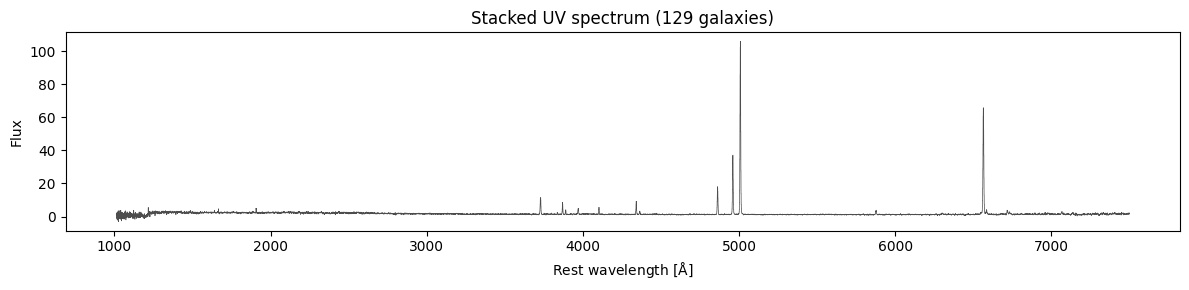

In [3]:
# Quick look — mask NaN regions
valid = stack.mask_valid()

fig, ax = plt.subplots(figsize=(12, 3))
ax.step(stack.wave_A[valid], stack.flux_ujy[valid], where="mid", lw=0.5, color="0.3")
ax.set_xlabel(r"Rest wavelength [$\mathrm{\AA}$]")
ax.set_ylabel("Flux")
ax.set_title("Stacked UV spectrum (129 galaxies)")
plt.tight_layout()

## Fit Hα + [NII] + [OIII] 5007

Fit the optical emission lines in the rest-frame stack. Since this
is at z=0, we specify the lines explicitly and use R=150.

In [ ]:
optical_lines = ["OIII_5007", "Ha", "NII_6549", "NII_6585"]

result_opt = jwspecfit.fit_with_broad(
    stack, z=0.0, R=150.0,
    lines=optical_lines,
    mode="auto",
    n_boot=200,
)

print(f"Selected model: {result_opt.selected_model}")
print(f"BIC — narrow: {result_opt.bic_narrow:.1f}, broad1: {result_opt.bic_broad1:.1f}, "
      f"broad2: {result_opt.bic_broad2:.1f}, both: {result_opt.bic_both:.1f}")
print(f"\nχ²/dof = {result_opt.best_fit.chi2:.2f}")
print()
for name, lr in result_opt.best_fit.lines.items():
    print(f"  {name:<18s} flux={lr.flux:.3e} ± {lr.flux_err:.3e}  SNR={lr.snr:.1f}")

In [ ]:
# Matplotlib plot
fig = jwspecfit.plot_fit(result_opt.best_fit, wave_unit="A")
fig.suptitle("Stacked spectrum — optical lines", y=1.02)
plt.show()

In [ ]:
# Interactive plotly plot
fig_interactive = jwspecfit.plot_fit_interactive(result_opt.best_fit, wave_unit="A")
fig_interactive.show()

## Auto-detected R from pixel spacing

If you don't know the effective R, `jwspecfit` can estimate it from
the pixel spacing (assuming Nyquist sampling).

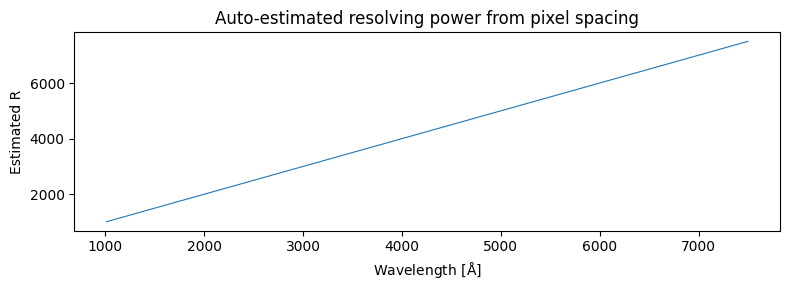

In [10]:
# Make a copy with no R set
stack_auto = stack.copy()
stack_auto.R = None

# R_from_pixels returns a callable R(λ)
R_fn = jwspecfit.R_from_pixels(stack_auto.wave_um)
R_estimated = R_fn(stack_auto.wave_um)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(stack_auto.wave_A[valid], R_estimated[valid], lw=0.8)
ax.set_xlabel(r"Wavelength [$\mathrm{\AA}$]")
ax.set_ylabel("Estimated R")
ax.set_title("Auto-estimated resolving power from pixel spacing")
plt.tight_layout()

## IGM transmission model

The Inoue et al. (2014) mean IGM transmission for a source at different
redshifts.  This is applied to the Lyman-alpha model automatically.

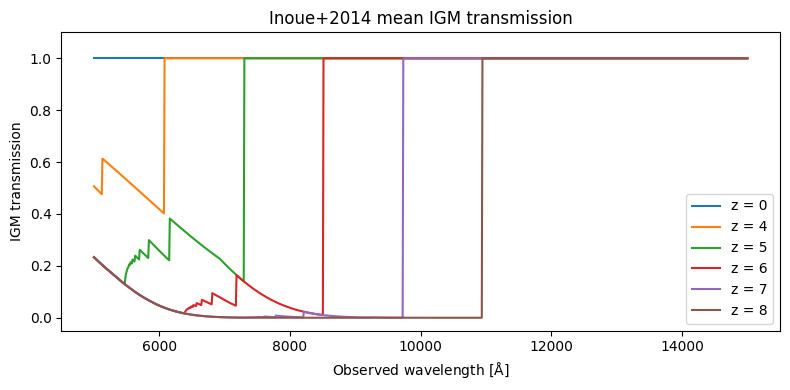

In [7]:
wave_obs = np.linspace(5000, 15000, 1000)  # Å

fig, ax = plt.subplots(figsize=(8, 4))
for z in [0,4.0, 5.0, 6.0, 7.0, 8.0]:
    T = igm_transmission(wave_obs, z_source=z)
    ax.plot(wave_obs, T, label=f"z = {z:.0f}")

ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]")
ax.set_ylabel("IGM transmission")
ax.set_title("Inoue+2014 mean IGM transmission")
ax.legend()
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()

## Skewed Lyman-alpha model

Lyα is modelled as a skewed Gaussian (red-asymmetric) attenuated by IGM.

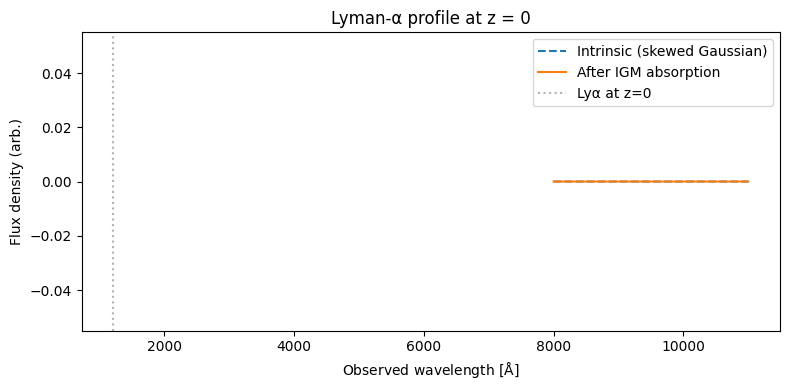

In [8]:
from jwspecfit.lyman_alpha import lya_model, skewed_gaussian_binned

z = 0
mu = 1215.67 * (1 + z)  # Observed Lyα
sigma = 30.0  # Å
skew = 5.0    # Positive = red tail

left = np.arange(8000, 11000, 2.0)
right = left + 2.0
centres = 0.5 * (left + right)

intrinsic = skewed_gaussian_binned(left, right, 1.0, mu, sigma, skew)
attenuated = lya_model(left, right, z, 1.0, mu, sigma, skew)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(centres, intrinsic, label="Intrinsic (skewed Gaussian)", ls="--")
ax.plot(centres, attenuated, label="After IGM absorption")
ax.axvline(mu, color="0.7", ls=":", label=f"Lyα at z={z}")
ax.set_xlabel(r"Observed wavelength [$\mathrm{\AA}$]")
ax.set_ylabel("Flux density (arb.)")
ax.set_title(f"Lyman-α profile at z = {z}")
ax.legend()
plt.tight_layout()